In [89]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
# Library untuk cek ditribusi
from scipy.stats import norm
# library untuk korelasi variable object
from scipy.stats import chi2_contingency
# Library untuk metode RFM
from lifetimes import BetaGeoFitter
from lifetimes.utils import summary_data_from_transaction_data
# Library untuk uji hipotesis
from scipy.stats import kruskal
# Library untuk prediksi
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# **1. Data Overview**

In [90]:
# import data
df = pd.read_csv('C:\Dibimbing\Customer Segmentation\dataset\\Customer_Segmentation.csv')

In [91]:
# display dataframe maksimal
pd.set_option("display.max_columns", None)

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       100000 non-null  object 
 1   customer_id                    100000 non-null  object 
 2   order_status                   100000 non-null  object 
 3   order_purchase_timestamp       100000 non-null  object 
 4   order_approved_at              100000 non-null  object 
 5   order_delivered_timestamp      98464 non-null   object 
 6   order_estimated_delivery_date  100000 non-null  object 
 7   product_id                     100000 non-null  object 
 8   seller_id                      100000 non-null  object 
 9   price                          100000 non-null  float64
 10  shipping_charges               100000 non-null  float64
 11  product_category_name          99981 non-null   object 
 12  product_weight_g               

In [93]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value,customer_zip_code_prefix,customer_city,customer_state
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,90K0C1fIyQUf,ZWM05J9LcBSF,223.51,84.65,toys,491.0,19.0,12.0,16.0,1,credit_card,1,259.14,58125,varzea paulista,SP
1,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,90K0C1fIyQUf,ZWM05J9LcBSF,223.51,84.65,toys,491.0,19.0,12.0,16.0,1,credit_card,1,259.14,58125,varzea paulista,SP
2,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,90K0C1fIyQUf,ZWM05J9LcBSF,223.51,84.65,toys,491.0,19.0,12.0,16.0,1,credit_card,1,259.14,58125,varzea paulista,SP
3,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,90K0C1fIyQUf,ZWM05J9LcBSF,223.51,84.65,toys,491.0,19.0,12.0,16.0,1,credit_card,1,259.14,58125,varzea paulista,SP
4,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,90K0C1fIyQUf,ZWM05J9LcBSF,223.51,84.65,toys,491.0,19.0,12.0,16.0,1,credit_card,1,259.14,58125,varzea paulista,SP


In [94]:
df.shape

(100000, 23)

- jumlah baris: 100.000
- jumlah kolom: 23

In [95]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_timestamp',
       'order_estimated_delivery_date', 'product_id', 'seller_id', 'price',
       'shipping_charges', 'product_category_name', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value', 'customer_zip_code_prefix', 'customer_city',
       'customer_state'],
      dtype='object')

In [96]:
df.dtypes

order_id                          object
customer_id                       object
order_status                      object
order_purchase_timestamp          object
order_approved_at                 object
order_delivered_timestamp         object
order_estimated_delivery_date     object
product_id                        object
seller_id                         object
price                            float64
shipping_charges                 float64
product_category_name             object
product_weight_g                 float64
product_length_cm                float64
product_height_cm                float64
product_width_cm                 float64
payment_sequential                 int64
payment_type                      object
payment_installments               int64
payment_value                    float64
customer_zip_code_prefix           int64
customer_city                     object
customer_state                    object
dtype: object

- Untuk data date masih dalam bentuk object

In [97]:
df.describe()

,price,shipping_charges,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_installments,payment_value,customer_zip_code_prefix
count,100000.000000,100000.000000,99986.000000,99986.000000,99986.000000,99986.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,519.373862,45.021183,1817.657352,31.478117,15.751065,24.961575,1.104740,2.587790,297.371103,40043.759870
std,872.859682,42.807050,2543.057379,14.562938,10.441849,11.032317,0.861195,2.552645,387.492636,30602.253486
min,0.850000,0.070000,0.000000,7.000000,2.000000,7.000000,1.000000,1.000000,0.200000,1004.000000
25%,89.100000,19.630000,396.000000,20.000000,10.000000,15.000000,1.000000,1.000000,85.360000,9655.000000
50%,159.900000,34.330000,1110.000000,30.000000,12.000000,20.000000,1.000000,1.000000,170.760000,35938.000000
75%,564.990000,54.420000,1750.000000,42.000000,22.000000,30.000000,1.000000,3.000000,336.060000,68458.000000
max,4590.000000,321.880000,30000.000000,105.000000,105.000000,105.000000,23.000000,24.000000,6929.310000,99990.000000


**Price**

* **Mean (519) jauh lebih tinggi dari median (159)** → distribusi **right-skewed (tidak normal)**
* **Std sangat besar (872)** → variasi harga sangat tinggi
* **Max (4590) vs Q3 (564)** → ada **outlier signifikan**
* **Insight:** mayoritas produk murah–menengah, tapi ada sedikit produk premium yang “menarik” rata-rata ke atas
---
**Shipping Charges**

* **Mean (45) > median (34)** → **right-skewed**
* **Max (321) jauh di atas Q3 (54)** → indikasi **outlier ongkir tinggi**
* Variasi cukup tinggi (std ≈ 42)
* **Insight:** sebagian kecil transaksi memiliki ongkir sangat mahal (kemungkinan barang besar / lokasi jauh)
---
**Product Weight (gram)**

* **Mean (1817) > median (1110)** → **right-skewed**
* **Max (30.000 gram)** sangat jauh dari Q3 (1750) → **outlier ekstrem**
* Ada nilai **0** → kemungkinan **data error / missing disguised as 0**
* **Insight:** mayoritas produk ringan, tapi ada produk sangat berat (mempengaruhi ongkir)
---
**Payment Installments**

* Mean (2.58) > median (1) → **right-skewed**
* Max (24)** → ada cicilan panjang
* Q1 & median = 1 → mayoritas **bayar langsung (no installment)**
* **Insight:** sebagian kecil user menggunakan cicilan → potensi segmentasi customer
---
**Payment Value**

* Mean (297) > median (170) → **right-sked**
* Std tinggi (387) → variasi besar
* Max (6929) vs Q3 (336) → **outlier besar**
* **Insight:** mirip price → ada transaksi high-value yang menarik rata-rata


In [98]:
df.describe(include='O')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,product_id,seller_id,product_category_name,payment_type,customer_city,customer_state
count,100000,100000,100000,100000,100000,98464,100000,100000,100000,99981,100000,100000,100000
unique,3640,3640,5,3581,3564,3499,397,2854,1061,54,4,910,25
top,FRHuSNR1NFDV,ihuumC3xhJjU,delivered,2017-05-16 10:49:27,2017-05-16 11:05:10,2017-05-23 12:42:16,2017-12-05,0vbEvli2JYJu,r7VxefoTVHbb,toys,credit_card,sao paulo,SP
freq,405,405,98464,810,810,810,1325,7574,15368,75157,69385,13541,38986


In [99]:
# Pemeriksaan unique value
obj_col = df.select_dtypes(include=["object"]).columns
obj_value = []

for col in obj_col:
    obj_value.append({
        "column_name": col,
        "n_unique": df[col].nunique(dropna=True),
        "n_missing": df[col].isna().sum(),
        "top_5_value": df[col].value_counts().head(5).to_dict()
    })

df_obj_value = pd.DataFrame(obj_value)

df_obj_value

,column_name,n_unique,n_missing,top_5_value
0,order_id,3640,0,"{'FRHuSNR1NFDV': 405, '6nQTVRCEs8s5': 405, 've..."
1,customer_id,3640,0,"{'ihuumC3xhJjU': 405, 'CsTukFYasFI4': 405, 'U1..."
2,order_status,5,0,"{'delivered': 98464, 'shipped': 1140, 'process..."
3,order_purchase_timestamp,3581,0,"{'2017-05-16 10:49:27': 810, '2017-09-23 12:53..."
4,order_approved_at,3564,0,"{'2017-05-16 11:05:10': 810, '2017-05-07 23:02..."
5,order_delivered_timestamp,3499,1536,"{'2017-05-23 12:42:16': 810, '2017-04-25 09:44..."
6,order_estimated_delivery_date,397,0,"{'2017-12-05': 1325, '2018-03-15': 1227, '2018..."
7,product_id,2854,0,"{'0vbEvli2JYJu': 7574, '9NwzO0Pm0fDM': 6128, '..."
8,seller_id,1061,0,"{'r7VxefoTVHbb': 15368, 'RKad98cTxhSb': 9166, ..."
9,product_category_name,54,19,"{'toys': 75157, 'health_beauty': 4869, 'comput..."


In [100]:
# periksa jumlah duplikat
print(f'jumlah duplikat: {df.duplicated().sum()}')

jumlah duplikat: 96360


In [101]:
# periksa jumlah unique order_id
df['order_id'].nunique()

3640

In [102]:
# periksa jumlah unique customer_id
df['customer_id'].nunique()

3640

In [103]:
df.groupby('order_id').size().sort_values(ascending=False)

order_id
VGnTuPH9ikhV    405
FRHuSNR1NFDV    405
HJRxFIlRAAQ3    405
I43d5C2eIKIg    405
G2XW35v6GEqh    405
               ... 
zN4BuXRy3YVN      1
0inavJn0i3vT      1
0YHf7JIvGIbl      1
QWnrxS8aTLYf      1
QQPRyaI3i3N6      1
Length: 3640, dtype: int64

- 1 order_id ada yang memiliki duplikat data hingga 405, dimana hal tersebut tidak wajar untuk data e-commerce. Sehingga hal tersebut dapat menjadi indikasi yang kuat bahwa duplikat yang dimiliki dataset merupakan duplikat asli

In [104]:
df.duplicated(subset=['order_id', 'product_id'])

0        False
1         True
2         True
3         True
4         True
         ...  
99995     True
99996     True
99997     True
99998     True
99999     True
Length: 100000, dtype: bool

In [105]:
df.duplicated(subset=['order_id', 'product_id']).sum()

np.int64(96360)

- hasil True, memiliki indikasi bahwa duplikat memiliki kombinasi order_id dan product_id yang sama (bukan detail dalam 1 order memiliki beberapa produk)

In [106]:
df[df.duplicated(keep=False)]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value,customer_zip_code_prefix,customer_city,customer_state
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,90K0C1fIyQUf,ZWM05J9LcBSF,223.51,84.65,toys,491.0,19.0,12.0,16.0,1,credit_card,1,259.14,58125,varzea paulista,SP
1,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,90K0C1fIyQUf,ZWM05J9LcBSF,223.51,84.65,toys,491.0,19.0,12.0,16.0,1,credit_card,1,259.14,58125,varzea paulista,SP
2,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,90K0C1fIyQUf,ZWM05J9LcBSF,223.51,84.65,toys,491.0,19.0,12.0,16.0,1,credit_card,1,259.14,58125,varzea paulista,SP
3,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,90K0C1fIyQUf,ZWM05J9LcBSF,223.51,84.65,toys,491.0,19.0,12.0,16.0,1,credit_card,1,259.14,58125,varzea paulista,SP
4,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,90K0C1fIyQUf,ZWM05J9LcBSF,223.51,84.65,toys,491.0,19.0,12.0,16.0,1,credit_card,1,259.14,58125,varzea paulista,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,GeG4KAwtrR78,uqCUB2mTXtlt,delivered,2017-09-22 15:26:28,2017-09-23 18:44:28,2017-09-28 18:48:56,2017-10-16,0vbEvli2JYJu,RKad98cTxhSb,95.03,59.62,toys,1383.0,50.0,10.0,40.0,1,credit_card,2,2759.95,56327,guarulhos,SP
99996,GeG4KAwtrR78,uqCUB2mTXtlt,delivered,2017-09-22 15:26:28,2017-09-23 18:44:28,2017-09-28 18:48:56,2017-10-16,0vbEvli2JYJu,RKad98cTxhSb,95.03,59.62,toys,1383.0,50.0,10.0,40.0,1,credit_card,2,2759.95,56327,guarulhos,SP
99997,GeG4KAwtrR78,uqCUB2mTXtlt,delivered,2017-09-22 15:26:28,2017-09-23 18:44:28,2017-09-28 18:48:56,2017-10-16,0vbEvli2JYJu,RKad98cTxhSb,95.03,59.62,toys,1383.0,50.0,10.0,40.0,1,credit_card,2,2759.95,56327,guarulhos,SP
99998,GeG4KAwtrR78,uqCUB2mTXtlt,delivered,2017-09-22 15:26:28,2017-09-23 18:44:28,2017-09-28 18:48:56,2017-10-16,0vbEvli2JYJu,RKad98cTxhSb,95.03,59.62,toys,1383.0,50.0,10.0,40.0,1,credit_card,2,2759.95,56327,guarulhos,SP


In [107]:
df[df.duplicated()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value,customer_zip_code_prefix,customer_city,customer_state
1,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,90K0C1fIyQUf,ZWM05J9LcBSF,223.51,84.65,toys,491.0,19.0,12.0,16.0,1,credit_card,1,259.14,58125,varzea paulista,SP
2,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,90K0C1fIyQUf,ZWM05J9LcBSF,223.51,84.65,toys,491.0,19.0,12.0,16.0,1,credit_card,1,259.14,58125,varzea paulista,SP
3,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,90K0C1fIyQUf,ZWM05J9LcBSF,223.51,84.65,toys,491.0,19.0,12.0,16.0,1,credit_card,1,259.14,58125,varzea paulista,SP
4,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,90K0C1fIyQUf,ZWM05J9LcBSF,223.51,84.65,toys,491.0,19.0,12.0,16.0,1,credit_card,1,259.14,58125,varzea paulista,SP
5,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,90K0C1fIyQUf,ZWM05J9LcBSF,223.51,84.65,toys,491.0,19.0,12.0,16.0,1,credit_card,1,259.14,58125,varzea paulista,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,GeG4KAwtrR78,uqCUB2mTXtlt,delivered,2017-09-22 15:26:28,2017-09-23 18:44:28,2017-09-28 18:48:56,2017-10-16,0vbEvli2JYJu,RKad98cTxhSb,95.03,59.62,toys,1383.0,50.0,10.0,40.0,1,credit_card,2,2759.95,56327,guarulhos,SP
99996,GeG4KAwtrR78,uqCUB2mTXtlt,delivered,2017-09-22 15:26:28,2017-09-23 18:44:28,2017-09-28 18:48:56,2017-10-16,0vbEvli2JYJu,RKad98cTxhSb,95.03,59.62,toys,1383.0,50.0,10.0,40.0,1,credit_card,2,2759.95,56327,guarulhos,SP
99997,GeG4KAwtrR78,uqCUB2mTXtlt,delivered,2017-09-22 15:26:28,2017-09-23 18:44:28,2017-09-28 18:48:56,2017-10-16,0vbEvli2JYJu,RKad98cTxhSb,95.03,59.62,toys,1383.0,50.0,10.0,40.0,1,credit_card,2,2759.95,56327,guarulhos,SP
99998,GeG4KAwtrR78,uqCUB2mTXtlt,delivered,2017-09-22 15:26:28,2017-09-23 18:44:28,2017-09-28 18:48:56,2017-10-16,0vbEvli2JYJu,RKad98cTxhSb,95.03,59.62,toys,1383.0,50.0,10.0,40.0,1,credit_card,2,2759.95,56327,guarulhos,SP


In [108]:
df.groupby(['order_id','product_id']).nunique()

,,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value,customer_zip_code_prefix,customer_city,customer_state
order_id,product_id,,,,,,,,,,,,,,,,,,,,,
00NEIdaOTIgn,Mh5csf65CB6I,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
019iNT2eSEYM,mqrnNPLgsDKO,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
05Tyg0HKJJgw,dj10itAmtmuL,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
06lksMy92rUv,CtIL1bAdGNzV,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
072xMq8A0d39,4VIws8ixtz0J,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zvfNEMMH7it2,2QbjRpmjbf1Z,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
zw5wbnYc9TBM,ztsuOjhk9HKD,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
zxVWgghkguth,H2H6xWAqc2VD,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


- semua kolom unik, artinya duplikat yang ditemukan adalah duplikat murni, sehingga dapat dihapus

In [109]:
# membuat dataframe copy (dfc)
dfc = df.copy()

In [110]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       100000 non-null  object 
 1   customer_id                    100000 non-null  object 
 2   order_status                   100000 non-null  object 
 3   order_purchase_timestamp       100000 non-null  object 
 4   order_approved_at              100000 non-null  object 
 5   order_delivered_timestamp      98464 non-null   object 
 6   order_estimated_delivery_date  100000 non-null  object 
 7   product_id                     100000 non-null  object 
 8   seller_id                      100000 non-null  object 
 9   price                          100000 non-null  float64
 10  shipping_charges               100000 non-null  float64
 11  product_category_name          99981 non-null   object 
 12  product_weight_g               

In [111]:
dfc = dfc.drop_duplicates()

In [112]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3640 entries, 0 to 99716
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       3640 non-null   object 
 1   customer_id                    3640 non-null   object 
 2   order_status                   3640 non-null   object 
 3   order_purchase_timestamp       3640 non-null   object 
 4   order_approved_at              3640 non-null   object 
 5   order_delivered_timestamp      3559 non-null   object 
 6   order_estimated_delivery_date  3640 non-null   object 
 7   product_id                     3640 non-null   object 
 8   seller_id                      3640 non-null   object 
 9   price                          3640 non-null   float64
 10  shipping_charges               3640 non-null   float64
 11  product_category_name          3633 non-null   object 
 12  product_weight_g               3639 non-null   float

In [113]:
dfc.shape

(3640, 23)

- jumlah baris: 3640
- jumlah kolom: 23

In [114]:
dfc.describe()

,price,shipping_charges,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_installments,payment_value,customer_zip_code_prefix
count,3640.000000,3640.000000,3639.000000,3639.000000,3639.000000,3639.000000,3640.000000,3640.000000,3640.000000,3640.000000
mean,342.945201,44.583717,2055.493267,30.344051,16.536136,23.197307,1.099725,2.975549,274.662022,39762.278846
std,547.106930,38.949894,3524.037335,16.218370,13.371495,11.947249,0.759080,2.855445,357.847021,30955.969945
min,0.850000,0.070000,0.000000,7.000000,2.000000,7.000000,1.000000,1.000000,0.200000,1004.000000
25%,68.075000,20.490000,300.000000,18.000000,8.000000,15.000000,1.000000,1.000000,87.557500,9687.750000
50%,142.140000,34.790000,700.000000,25.000000,13.000000,20.000000,1.000000,2.000000,174.240000,34521.000000
75%,403.900000,56.090000,1800.000000,38.000000,20.000000,30.000000,1.000000,4.000000,321.742500,68543.000000
max,4590.000000,321.880000,30000.000000,105.000000,105.000000,105.000000,23.000000,24.000000,6929.310000,99990.000000


**Price**

* Mean (342) jauh lebih tinggi dari median (142) → distribusi right-skewed (tidak normal)
* Std cukup besar (547) → variasi harga tinggi
* Max (4590) vs Q3 (403) → ada outlier signifikan
* Insight: mayoritas produk low–mid price, dengan sedikit produk high-value

---

**Shipping Charges**

* Mean (44.5) lebih tinggi dari median (34.7) → right-skewed
* Std cukup tinggi (38.9) → variasi ongkir besar
* Max (321) vs Q3 (56) → terdapat outlier
* Insight: ongkir sangat bervariasi, kemungkinan dipengaruhi berat dan lokasi

---

**Payment Sequential**

* Mean (1.09) ≈ median (1) → mayoritas single payment
* Max (23) → ada transaksi dengan banyak tahapan pembayaran
* Insight: sebagian kecil user melakukan multiple payment

---

**Payment Installments**

* Mean (2.97) > median (2) → right-skewed
* Q1 = 1 → banyak transaksi tanpa cicilan
* Max (24) → ada cicilan panjang
* Insight: terdapat segmentasi user antara bayar langsung vs cicilan

---

**Payment Value**

* Mean (274) > median (174) → right-skewed
* Std tinggi (357) → variasi besar
* Max (6929) vs Q3 (321) → outlier signifikan
* Insight: terdapat transaksi high-value yang menarik rata-rata naik


In [115]:
dfc.describe(include='O')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,product_id,seller_id,product_category_name,payment_type,customer_city,customer_state
count,3640,3640,3640,3640,3640,3559,3640,3640,3640,3633,3640,3640,3640
unique,3640,3640,5,3581,3564,3499,397,2854,1061,54,4,910,25
top,GeG4KAwtrR78,uqCUB2mTXtlt,delivered,2018-06-07 22:32:24,2018-06-07 22:55:51,2018-06-18 14:31:22,2018-07-16,0vbEvli2JYJu,RKad98cTxhSb,toys,credit_card,sao paulo,SP
freq,1,1,3559,4,4,4,25,19,65,2778,2703,591,1507


In [116]:
# Pemeriksaan unique value
obj_col = dfc.select_dtypes(include=["object"]).columns
obj_value = []

for col in obj_col:
    obj_value.append({
        "column_name": col,
        "n_unique": dfc[col].nunique(dropna=True),
        "n_missing": dfc[col].isna().sum(),
        "top_5_value": dfc[col].value_counts().head(5).to_dict()
    })

dfc_obj_value = pd.DataFrame(obj_value)

dfc_obj_value

,column_name,n_unique,n_missing,top_5_value
0,order_id,3640,0,"{'GeG4KAwtrR78': 1, 'Axfy13Hk4PIk': 1, 'v6px92..."
1,customer_id,3640,0,"{'uqCUB2mTXtlt': 1, 'hCT0x9JiGXBQ': 1, 'PxA7fv..."
2,order_status,5,0,"{'delivered': 3559, 'shipped': 45, 'canceled':..."
3,order_purchase_timestamp,3581,0,"{'2018-06-07 22:32:24': 4, '2017-08-23 09:22:3..."
4,order_approved_at,3564,0,"{'2018-06-07 22:55:51': 4, '2018-07-23 12:32:1..."
5,order_delivered_timestamp,3499,81,"{'2018-06-18 14:31:22': 4, '2017-09-02 12:13:0..."
6,order_estimated_delivery_date,397,0,"{'2018-07-16': 25, '2018-07-17': 24, '2018-06-..."
7,product_id,2854,0,"{'0vbEvli2JYJu': 19, 'GvBzGCvvIC2D': 17, '9Nwz..."
8,seller_id,1061,0,"{'RKad98cTxhSb': 65, 'ruq0u2ZpAMDr': 57, 'K0qP..."
9,product_category_name,54,7,"{'toys': 2778, 'bed_bath_table': 95, 'sports_l..."


- order_delivered_timestamp: memiliki missing value, namun diintrepretasikan sebagai pesanan yang belum sampai ke customer
- product_category_name Terbanyak: Toys (2.778), serta terdapat 7 missing value
- payment_type Terbanyak: creditcard (2.703)
- customer_city Terbanyak: sao paulo (591)
- customer_state: SP (1.507)

In [117]:
# Pemeriksaan missing value
dfc_na = pd.DataFrame({
	'missing_value' : dfc.isna().sum(),
	'percentage(%)' : round((dfc.isna().mean()*100), 2),
	'data_type' : dfc.dtypes
})

total_cells = dfc.shape[0] * dfc.shape[1]
total_missing = dfc_na["missing_value"].sum()
percentage_total = (total_missing / total_cells) * 100

print(dfc_na[dfc_na['missing_value'] > 0].sort_values(by="missing_value", ascending=False))
print("\n")
print("Jumlah missing value: ", total_missing)
print("Persentase missing value (%): ", round(percentage_total, 2))

                           missing_value  percentage(%) data_type
order_delivered_timestamp             81           2.23    object
product_category_name                  7           0.19    object
product_weight_g                       1           0.03   float64
product_length_cm                      1           0.03   float64
product_height_cm                      1           0.03   float64
product_width_cm                       1           0.03   float64


Jumlah missing value:  92
Persentase missing value (%):  0.11


- order_delivered_timestamp: dibiarkan
- product_category_name: diisi dengan 'unknown'
- untuk missing pada spesifikasi ukuran dan berat, dapat dihapus karena hanya 1 baris

In [118]:
dfc[dfc[['product_weight_g','product_length_cm','product_height_cm','product_width_cm']].isnull().any(axis=1)]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value,customer_zip_code_prefix,customer_city,customer_state
60099,LLpfRBTIDAMu,dGSyjhkgllzW,delivered,2017-06-04 17:44:18,2017-06-04 17:55:13,2017-06-14 16:38:11,2017-07-05,zX9HL81jfvr2,SgeUigb5Vbiv,0.85,47.55,toys,NaN,NaN,NaN,NaN,1,credit_card,4,235.32,68902,porto alegre,RS


# **2. Handling Issue**

In [119]:
# Mengisi missing value pada product_category_name dengan unknown
dfc.loc[dfc["product_category_name"].isnull(), "product_category_name"] = "unknown"

In [120]:
dfc.isnull().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                 0
order_delivered_timestamp        81
order_estimated_delivery_date     0
product_id                        0
seller_id                         0
price                             0
shipping_charges                  0
product_category_name             0
product_weight_g                  1
product_length_cm                 1
product_height_cm                 1
product_width_cm                  1
payment_sequential                0
payment_type                      0
payment_installments              0
payment_value                     0
customer_zip_code_prefix          0
customer_city                     0
customer_state                    0
dtype: int64

In [121]:
dfc = dfc.dropna(subset=['product_weight_g','product_length_cm','product_height_cm','product_width_cm'])

In [122]:
dfc.isnull().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                 0
order_delivered_timestamp        81
order_estimated_delivery_date     0
product_id                        0
seller_id                         0
price                             0
shipping_charges                  0
product_category_name             0
product_weight_g                  0
product_length_cm                 0
product_height_cm                 0
product_width_cm                  0
payment_sequential                0
payment_type                      0
payment_installments              0
payment_value                     0
customer_zip_code_prefix          0
customer_city                     0
customer_state                    0
dtype: int64

In [123]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3639 entries, 0 to 99716
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       3639 non-null   object 
 1   customer_id                    3639 non-null   object 
 2   order_status                   3639 non-null   object 
 3   order_purchase_timestamp       3639 non-null   object 
 4   order_approved_at              3639 non-null   object 
 5   order_delivered_timestamp      3558 non-null   object 
 6   order_estimated_delivery_date  3639 non-null   object 
 7   product_id                     3639 non-null   object 
 8   seller_id                      3639 non-null   object 
 9   price                          3639 non-null   float64
 10  shipping_charges               3639 non-null   float64
 11  product_category_name          3639 non-null   object 
 12  product_weight_g               3639 non-null   float

In [124]:
col_numeric = dfc.select_dtypes(include='number')
col_numeric

,price,shipping_charges,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_installments,payment_value,customer_zip_code_prefix
0,223.51,84.65,491.0,19.0,12.0,16.0,1,1,259.14,58125
13,170.80,23.79,440.0,18.0,14.0,17.0,1,8,382.39,3112
16,64.40,17.38,2200.0,16.0,16.0,16.0,1,4,249.25,4119
21,264.50,30.72,1450.0,68.0,3.0,48.0,1,2,27.79,18212
27,779.90,30.66,300.0,17.0,4.0,12.0,1,1,76.15,88868
...,...,...,...,...,...,...,...,...,...,...
99695,57.66,140.52,220.0,22.0,13.0,12.0,1,1,111.01,6872
99703,18.10,20.67,1075.0,40.0,20.0,30.0,1,2,183.12,79134
99711,206.57,1.12,775.0,35.0,9.0,15.0,1,3,494.42,8765
99713,71.49,16.06,250.0,16.0,16.0,16.0,1,1,388.51,9600


In [125]:
# Membuat tabel pemeriksaan outlier
# Metode pemriksaan outlier: IQR
outlier_summary = {}

for n in col_numeric:
    Q1 = dfc[n].quantile(0.25) # Mendapatkan nilai 25% dari dataset
    Q3 = dfc[n].quantile(0.75) # Mendapatkan nilai 75% dari dataset
    IQR = Q3 - Q1

    lowerbond = Q1 - 1.5*IQR # Medapatkan nilai batas bawah outlier
    upperbond = Q3 + 1.5*IQR # Medapatkan nilai batas atas outlier

    outlier = dfc[(dfc[n] < lowerbond) | (dfc[n] > upperbond)] # outlier adalah nilai diatas nilai uppperbond atau dibawah lowerbond

    # Variable untuk merangkum perhitungan metode IQR dalam bentuk dictionary
    outlier_summary[n] = {
        "lower_bond" : lowerbond,
        "upper_bond" : upperbond,
        "n_outlier" : len(outlier), # jumlah data yang termasuk outlier
        "percentage" : len(outlier)/len(dfc[n])*100 # persentase
    }

In [126]:
pd.DataFrame(outlier_summary)

,price,shipping_charges,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_installments,payment_value,customer_zip_code_prefix
lower_bond,-435.600000,-32.910000,-1950.000000,-12.000000,-10.000000,-7.500000,1.000000,-3.50000,-263.755000,-78593.75
upper_bond,907.600000,109.490000,4050.000000,68.000000,38.000000,52.500000,1.000000,8.50000,673.045000,156820.25
n_outlier,231.000000,229.000000,534.000000,113.000000,230.000000,85.000000,161.000000,264.00000,275.000000,0.00
percentage,6.347898,6.292938,14.674361,3.105249,6.320418,2.335807,4.424292,7.25474,7.557021,0.00


In [127]:
# Setting warna visualisasi global
plt.rcParams["figure.facecolor"] = "black"
plt.rcParams["axes.facecolor"] = "black"
plt.rcParams["text.color"] = "white"
plt.rcParams["axes.labelcolor"] = "white"
plt.rcParams["xtick.color"] = "white"
plt.rcParams["ytick.color"] = "white"
# Mengubah warna default komponen boxplot secara global menjadi putih
plt.rcParams["boxplot.boxprops.color"] = "white"
plt.rcParams["boxplot.whiskerprops.color"] = "white"
plt.rcParams["boxplot.capprops.color"] = "white"
plt.rcParams["boxplot.medianprops.color"] = "orange"  # Oranye untuk median

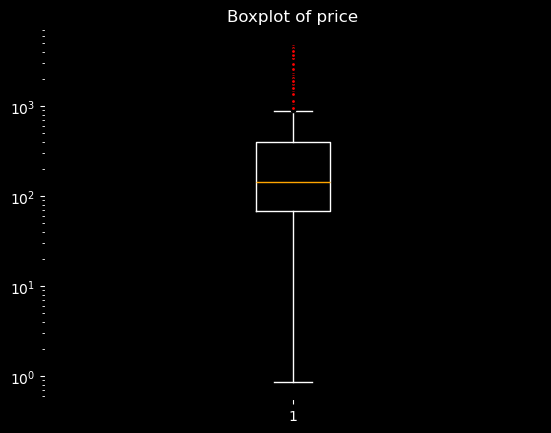

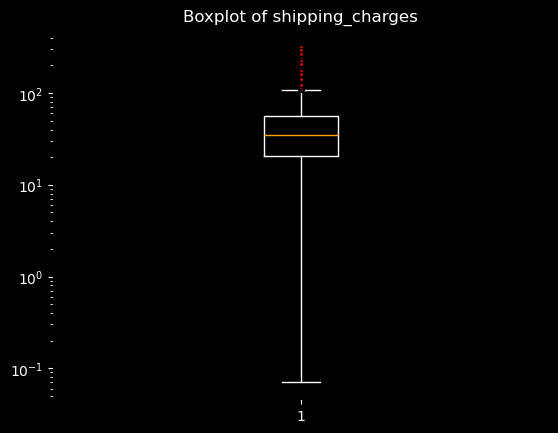

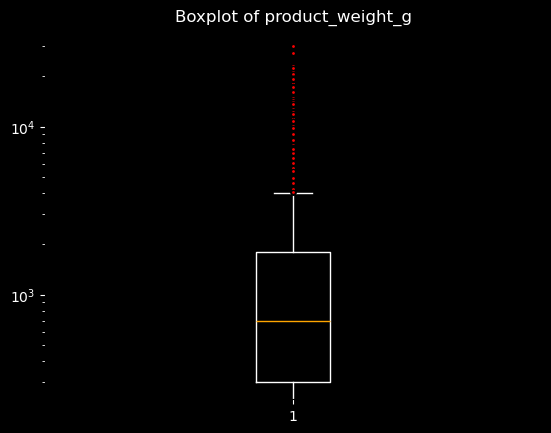

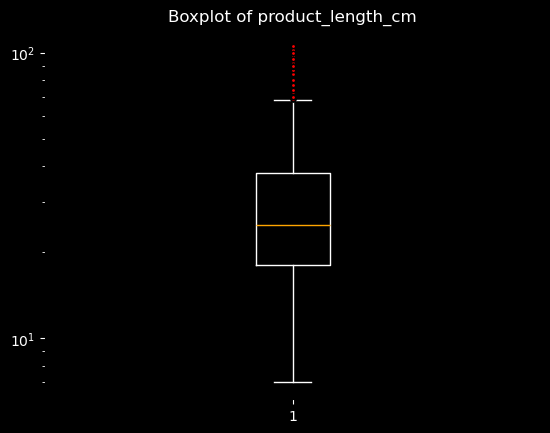

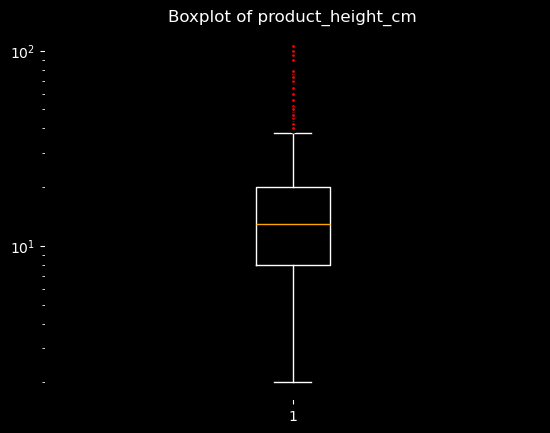

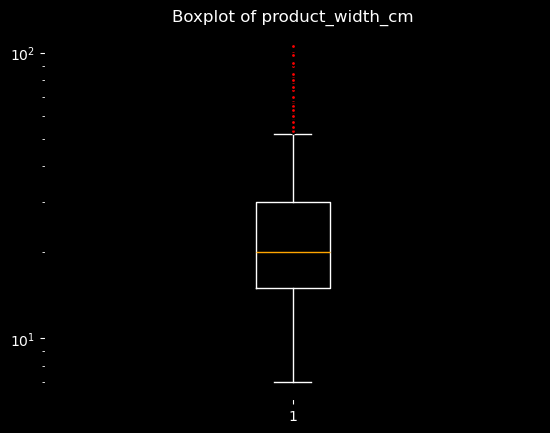

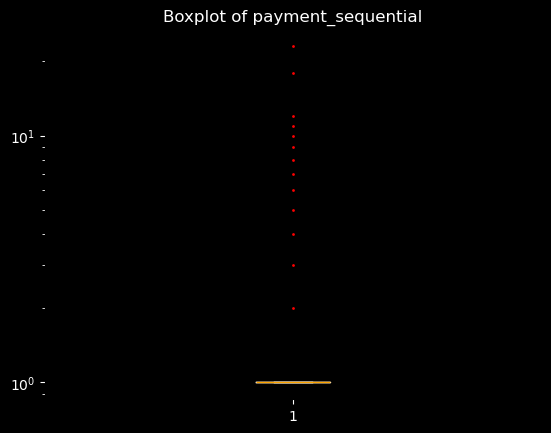

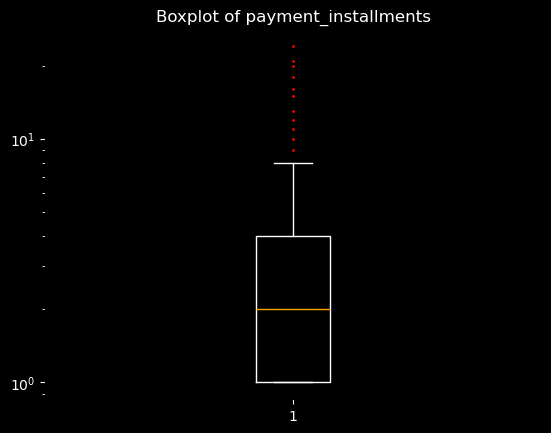

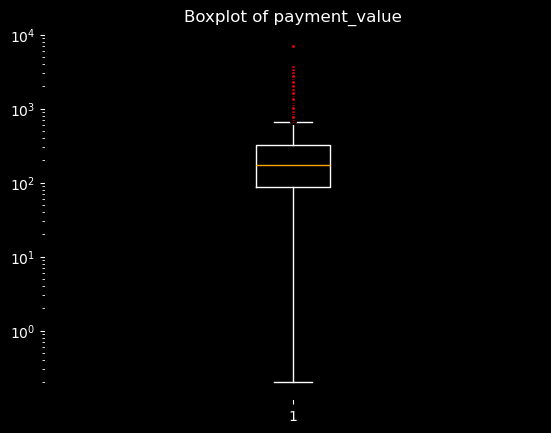

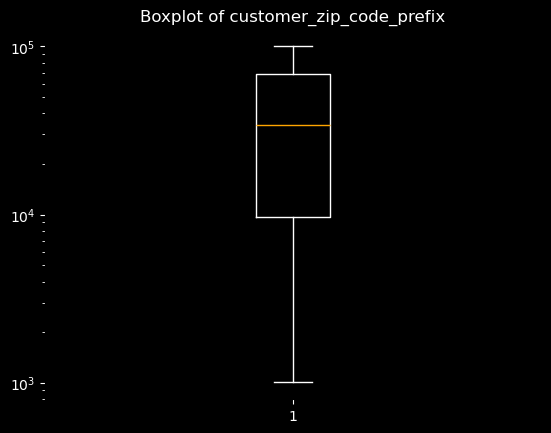

In [128]:
#membuat boxplot
for n in col_numeric:
    plt.figure()
    plt.boxplot(
        dfc[n],
        flierprops=dict(marker='o', markerfacecolor='red', markersize=3)
    )
    plt.yscale('log')  # scale digunakan karena jarak outlier terlalu jauh
    plt.title(f'Boxplot of {n}')
    plt.show()

- outlier dibiarkan karena dibutuhkan sebagai intrepretasi untuk representasi nilai tertentu

# **3. Data Manipulation**

In [129]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3639 entries, 0 to 99716
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       3639 non-null   object 
 1   customer_id                    3639 non-null   object 
 2   order_status                   3639 non-null   object 
 3   order_purchase_timestamp       3639 non-null   object 
 4   order_approved_at              3639 non-null   object 
 5   order_delivered_timestamp      3558 non-null   object 
 6   order_estimated_delivery_date  3639 non-null   object 
 7   product_id                     3639 non-null   object 
 8   seller_id                      3639 non-null   object 
 9   price                          3639 non-null   float64
 10  shipping_charges               3639 non-null   float64
 11  product_category_name          3639 non-null   object 
 12  product_weight_g               3639 non-null   float

In [130]:
# ubah kolom date dari object menjadi datetime
dfc['order_purchase_timestamp'] = pd.to_datetime(dfc['order_purchase_timestamp']).dt.date
dfc['order_approved_at'] = pd.to_datetime(dfc['order_approved_at']).dt.date
dfc['order_delivered_timestamp'] = pd.to_datetime(dfc['order_delivered_timestamp']).dt.date
dfc['order_estimated_delivery_date'] = pd.to_datetime(dfc['order_estimated_delivery_date'])

In [131]:
dfc.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp                 object
order_approved_at                        object
order_delivered_timestamp                object
order_estimated_delivery_date    datetime64[ns]
product_id                               object
seller_id                                object
price                                   float64
shipping_charges                        float64
product_category_name                    object
product_weight_g                        float64
product_length_cm                       float64
product_height_cm                       float64
product_width_cm                        float64
payment_sequential                        int64
payment_type                             object
payment_installments                      int64
payment_value                           float64
customer_zip_code_prefix                

In [132]:
dfc['order_purchase_timestamp'] = pd.to_datetime(dfc['order_purchase_timestamp'])
dfc['order_approved_at'] = pd.to_datetime(dfc['order_approved_at'])
dfc['order_delivered_timestamp'] = pd.to_datetime(dfc['order_delivered_timestamp'])

# buat kolom bulan (period bulanan) untuk Model ARIMA
dfc['year_month'] = dfc['order_purchase_timestamp'].dt.to_period('M')

In [133]:
dfc.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_timestamp        datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
product_id                               object
seller_id                                object
price                                   float64
shipping_charges                        float64
product_category_name                    object
product_weight_g                        float64
product_length_cm                       float64
product_height_cm                       float64
product_width_cm                        float64
payment_sequential                        int64
payment_type                             object
payment_installments                      int64
payment_value                           float64
customer_zip_code_prefix                

In [134]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3639 entries, 0 to 99716
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       3639 non-null   object        
 1   customer_id                    3639 non-null   object        
 2   order_status                   3639 non-null   object        
 3   order_purchase_timestamp       3639 non-null   datetime64[ns]
 4   order_approved_at              3639 non-null   datetime64[ns]
 5   order_delivered_timestamp      3558 non-null   datetime64[ns]
 6   order_estimated_delivery_date  3639 non-null   datetime64[ns]
 7   product_id                     3639 non-null   object        
 8   seller_id                      3639 non-null   object        
 9   price                          3639 non-null   float64       
 10  shipping_charges               3639 non-null   float64       
 11  product_category_name

In [135]:
# menbuat data frame data customer dan order
order_dfc = dfc.groupby(
    ['customer_id', 'order_id']
).agg(
    order_date=('order_purchase_timestamp', 'min'),
    revenue=('payment_value', 'sum')
).reset_index()

In [136]:
order_dfc

,customer_id,order_id,order_date,revenue
0,00FuuVIoeWKh,qbN6Og0aDSpJ,2018-01-22,162.86
1,00iM5unDGroS,dRU3OSNJJGQs,2018-02-10,393.32
2,02F4mgi0sl1v,Rc2my7o3fKo7,2018-04-11,18.22
3,03IKnHTxIfQh,EUiU39xGRM1f,2018-03-14,97.98
4,03m9PwcOYWpV,HGm0pzyUMEoV,2018-05-28,225.04
...,...,...,...,...
3634,zwFtWWaE2Ja8,M9UeVfUqd5IQ,2017-11-30,271.31
3635,zwzRltYelHrC,HoF4N2EdW9tF,2017-08-06,47.80
3636,zxnzAMXNhIRi,AUnUliUP4CbG,2017-10-16,65.93
3637,zyqhzTZ3KeBX,NyiQNFpZAtwl,2018-01-16,239.96


In [137]:
order_dfc.dtypes

customer_id            object
order_id               object
order_date     datetime64[ns]
revenue               float64
dtype: object

In [138]:
# variable tanggal terakhir customer melakukan purchase
observation_date = order_dfc['order_date'].max()

In [139]:
# membuat dataframe RFM
rfm = order_dfc.groupby('customer_id').agg(
    first_purchase=('order_date', 'min'),
    last_purchase=('order_date', 'max'),
    frequency=('order_id', 'nunique'),   # jumlah order
    monetary=('revenue', 'sum')         # average order value
).reset_index()

In [140]:
# Membuat kolom recency
rfm['recency'] = (rfm['last_purchase'] - rfm['first_purchase']).dt.days
# membuat kolom recency
rfm['T'] = (observation_date - rfm['first_purchase']).dt.days

In [141]:
# frequency 
rfm['frequency'] = rfm['frequency'] - 1

In [142]:
rfm

,customer_id,first_purchase,last_purchase,frequency,monetary,recency,T
0,00FuuVIoeWKh,2018-01-22,2018-01-22,0,162.86,0,219
1,00iM5unDGroS,2018-02-10,2018-02-10,0,393.32,0,200
2,02F4mgi0sl1v,2018-04-11,2018-04-11,0,18.22,0,140
3,03IKnHTxIfQh,2018-03-14,2018-03-14,0,97.98,0,168
4,03m9PwcOYWpV,2018-05-28,2018-05-28,0,225.04,0,93
...,...,...,...,...,...,...,...
3634,zwFtWWaE2Ja8,2017-11-30,2017-11-30,0,271.31,0,272
3635,zwzRltYelHrC,2017-08-06,2017-08-06,0,47.80,0,388
3636,zxnzAMXNhIRi,2017-10-16,2017-10-16,0,65.93,0,317
3637,zyqhzTZ3KeBX,2018-01-16,2018-01-16,0,239.96,0,225


- setelah membuat RFM dengan metode manual, hasilnya f dan r tidak memiliki nilai. Maka mambuat RFM menjadi tidak dimungkinkan karena 2 matric tidak memiliki nilai sehingga CLV tidak dapat dicari

In [143]:
summary = summary_data_from_transaction_data(
    dfc,
    customer_id_col='customer_id',
    datetime_col='order_purchase_timestamp',
    monetary_value_col='payment_value',
    observation_period_end=observation_date
)

In [144]:
print(summary)

              frequency  recency      T  monetary_value
customer_id                                            
00FuuVIoeWKh        0.0      0.0  219.0             0.0
00iM5unDGroS        0.0      0.0  200.0             0.0
02F4mgi0sl1v        0.0      0.0  140.0             0.0
03IKnHTxIfQh        0.0      0.0  168.0             0.0
03m9PwcOYWpV        0.0      0.0   93.0             0.0
...                 ...      ...    ...             ...
zwFtWWaE2Ja8        0.0      0.0  272.0             0.0
zwzRltYelHrC        0.0      0.0  388.0             0.0
zxnzAMXNhIRi        0.0      0.0  317.0             0.0
zyqhzTZ3KeBX        0.0      0.0  225.0             0.0
zyrXHvAWCqLt        0.0      0.0  229.0             0.0

[3639 rows x 4 columns]


- Membuat RFM dengan metode summary_data_from_transaction_data, seluruh parameter juga tidak memliki nilai kecuali T

maka dataset ini:
- frequnecy==0: hanya memiliki 1 order per 1 customer (tidak ada repeat order)
- recency==0: hanya ada 1 transaksi

In [145]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3639 entries, 0 to 99716
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       3639 non-null   object        
 1   customer_id                    3639 non-null   object        
 2   order_status                   3639 non-null   object        
 3   order_purchase_timestamp       3639 non-null   datetime64[ns]
 4   order_approved_at              3639 non-null   datetime64[ns]
 5   order_delivered_timestamp      3558 non-null   datetime64[ns]
 6   order_estimated_delivery_date  3639 non-null   datetime64[ns]
 7   product_id                     3639 non-null   object        
 8   seller_id                      3639 non-null   object        
 9   price                          3639 non-null   float64       
 10  shipping_charges               3639 non-null   float64       
 11  product_category_name

In [146]:
dfc.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value,customer_zip_code_prefix,customer_city,customer_state,year_month
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22,2017-10-22,2017-10-26,2017-11-09,90K0C1fIyQUf,ZWM05J9LcBSF,223.51,84.65,toys,491.0,19.0,12.0,16.0,1,credit_card,1,259.14,58125,varzea paulista,SP,2017-10
13,v6px92oS8cLG,PxA7fv9spyhx,delivered,2018-06-20,2018-06-20,2018-07-03,2018-07-24,qejhpMGGVcsl,IjlpYfhUbRQs,170.80,23.79,watches_gifts,440.0,18.0,14.0,17.0,1,credit_card,8,382.39,3112,armacao dos buzios,RJ,2018-06
16,Ulpf9skrhjfm,g3nXeJkGI0Qw,delivered,2018-02-16,2018-02-17,2018-02-27,2018-03-08,qUS5d2pEAyxJ,77p2EYxcM9MD,64.40,17.38,costruction_tools_garden,2200.0,16.0,16.0,16.0,1,credit_card,4,249.25,4119,jandira,SP,2018-02
21,bwJVWupf2keN,EOEsCQ6QlpIg,delivered,2018-08-18,2018-08-18,2018-08-27,2018-09-19,639iGvMyv0De,jWzS0ayv9TGf,264.50,30.72,toys,1450.0,68.0,3.0,48.0,1,credit_card,2,27.79,18212,uberlandia,MG,2018-08
27,Dd0QnrMk9Cj5,mVz5LO2Vd6cL,delivered,2017-12-22,2017-12-22,2018-01-05,2018-01-18,1lycYGcsic2F,l1pYW6GBnPMr,779.90,30.66,toys,300.0,17.0,4.0,12.0,1,credit_card,1,76.15,88868,ilhabela,SP,2017-12


In [147]:
# membuat kolom baru segment by value
dfc['value_segment'] = pd.qcut(
    dfc['payment_value'],
    q=4,
    labels=['Low', 'Mid-Low', 'Mid-High', 'High']
)

In [148]:
dfc['value_segment'].cat.categories

Index(['Low', 'Mid-Low', 'Mid-High', 'High'], dtype='object')

In [149]:
bins = pd.qcut(dfc['payment_value'], q=4, retbins=True)[1]

In [150]:
labels = ['Low', 'Mid-Low', 'Mid-High', 'High']

for i in range(len(labels)):
    print(f"{labels[i]}: {bins[i]} - {bins[i+1]}")

Low: 0.2 - 87.54499999999999
Mid-Low: 87.54499999999999 - 174.22
Mid-High: 174.22 - 321.745
High: 321.745 - 6929.31


In [151]:
# mengubah tipe data dari category menjadi object
dfc['value_segment'] = dfc['value_segment'].astype('object')

In [152]:
# membuat kolom lama waktu pengiriman
dfc['delivery_time'] = (dfc['order_delivered_timestamp'] - dfc['order_purchase_timestamp']).dt.days
# membuat kolom estimasi lama waktu pengiriman
dfc['estimated_time'] = (dfc['order_estimated_delivery_date'] - dfc['order_purchase_timestamp']).dt.days
# membuat kolom lama waktu delay
dfc['delay'] = dfc['delivery_time'] - dfc['estimated_time']

In [153]:
# kolom baru volume barang
dfc['volume'] = dfc['product_length_cm'] * dfc['product_height_cm'] * dfc['product_width_cm']
# kolom baru kerapatan barang
dfc['density'] = dfc['product_weight_g'] / dfc['volume']
# kolom baru ratio biaya ongkir dengan harga barang
dfc['shipping_ratio'] = round((dfc['shipping_charges'] / dfc['price']), 2)

# **4. Data Exploration**

In [154]:
dfc.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value,customer_zip_code_prefix,customer_city,customer_state,year_month,value_segment,delivery_time,estimated_time,delay,volume,density,shipping_ratio
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22,2017-10-22,2017-10-26,2017-11-09,90K0C1fIyQUf,ZWM05J9LcBSF,223.51,84.65,toys,491.0,19.0,12.0,16.0,1,credit_card,1,259.14,58125,varzea paulista,SP,2017-10,Mid-High,4.0,18,-14.0,3648.0,0.134594,0.38
13,v6px92oS8cLG,PxA7fv9spyhx,delivered,2018-06-20,2018-06-20,2018-07-03,2018-07-24,qejhpMGGVcsl,IjlpYfhUbRQs,170.80,23.79,watches_gifts,440.0,18.0,14.0,17.0,1,credit_card,8,382.39,3112,armacao dos buzios,RJ,2018-06,High,13.0,34,-21.0,4284.0,0.102708,0.14
16,Ulpf9skrhjfm,g3nXeJkGI0Qw,delivered,2018-02-16,2018-02-17,2018-02-27,2018-03-08,qUS5d2pEAyxJ,77p2EYxcM9MD,64.40,17.38,costruction_tools_garden,2200.0,16.0,16.0,16.0,1,credit_card,4,249.25,4119,jandira,SP,2018-02,Mid-High,11.0,20,-9.0,4096.0,0.537109,0.27
21,bwJVWupf2keN,EOEsCQ6QlpIg,delivered,2018-08-18,2018-08-18,2018-08-27,2018-09-19,639iGvMyv0De,jWzS0ayv9TGf,264.50,30.72,toys,1450.0,68.0,3.0,48.0,1,credit_card,2,27.79,18212,uberlandia,MG,2018-08,Low,9.0,32,-23.0,9792.0,0.148080,0.12
27,Dd0QnrMk9Cj5,mVz5LO2Vd6cL,delivered,2017-12-22,2017-12-22,2018-01-05,2018-01-18,1lycYGcsic2F,l1pYW6GBnPMr,779.90,30.66,toys,300.0,17.0,4.0,12.0,1,credit_card,1,76.15,88868,ilhabela,SP,2017-12,Low,14.0,27,-13.0,816.0,0.367647,0.04


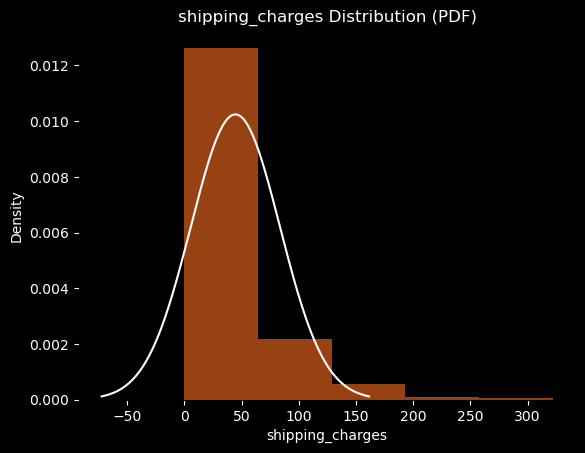

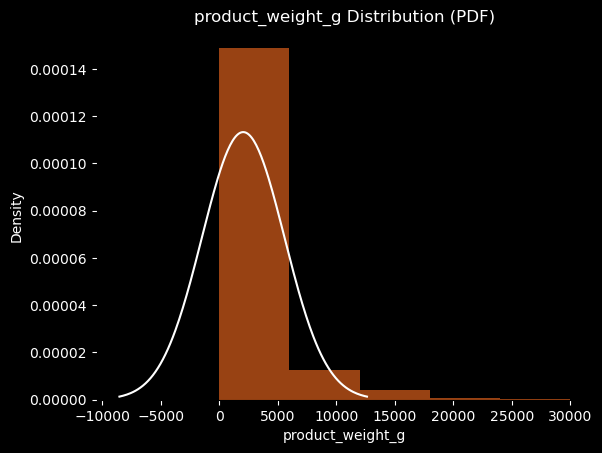

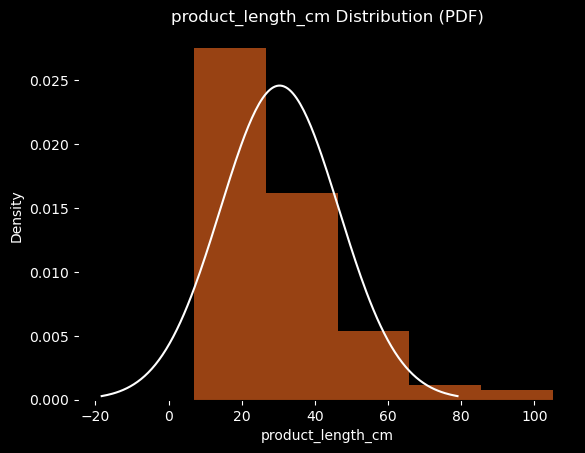

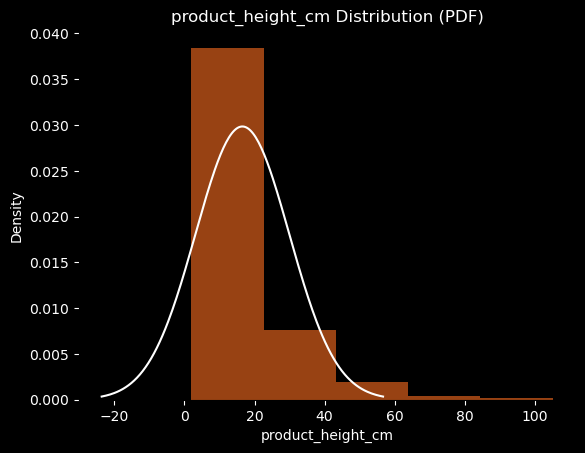

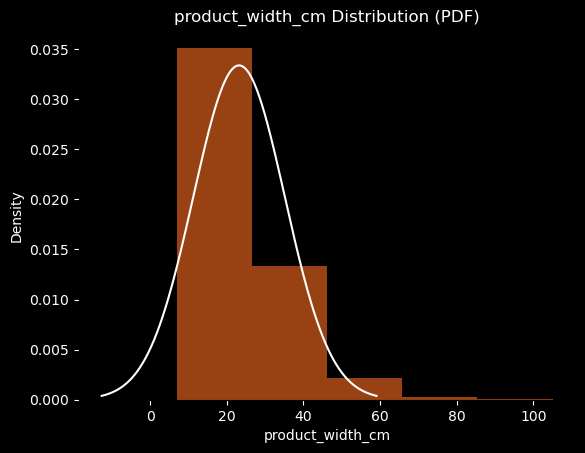

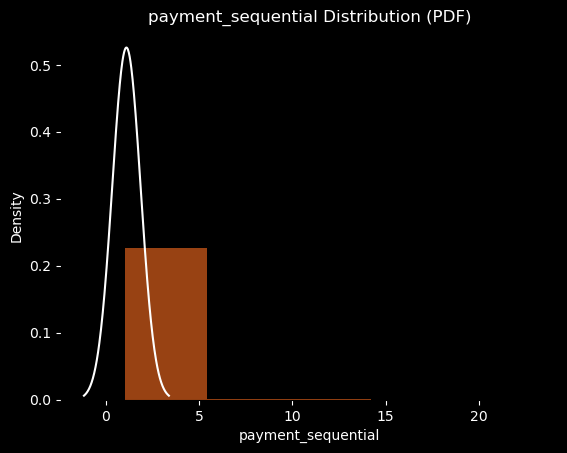

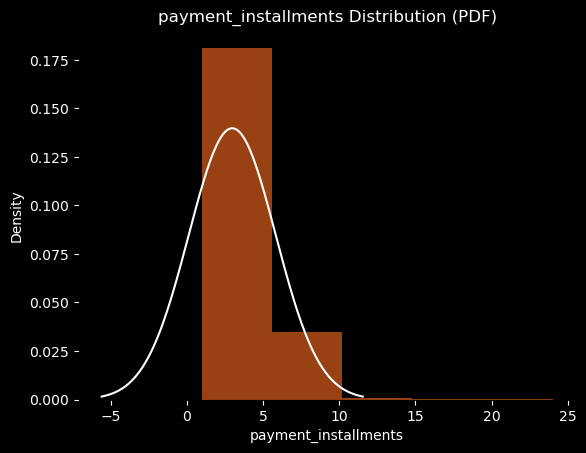

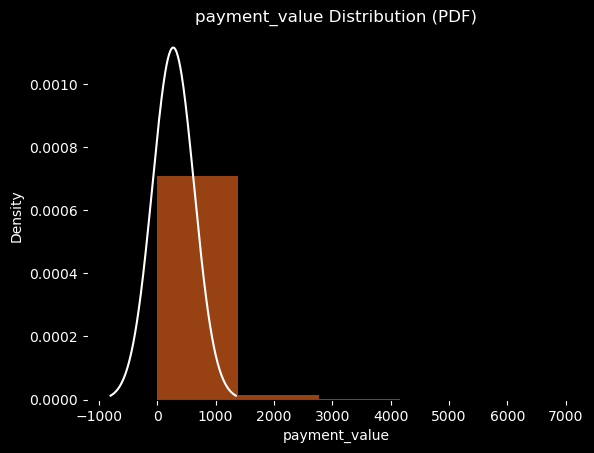

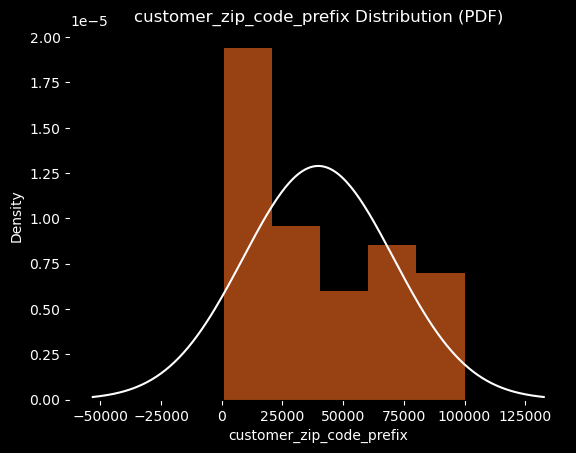

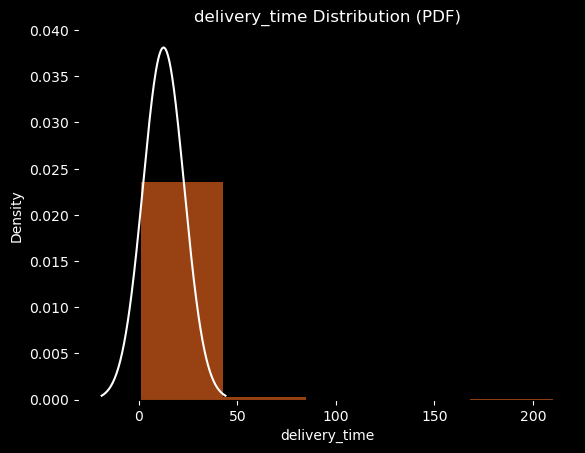

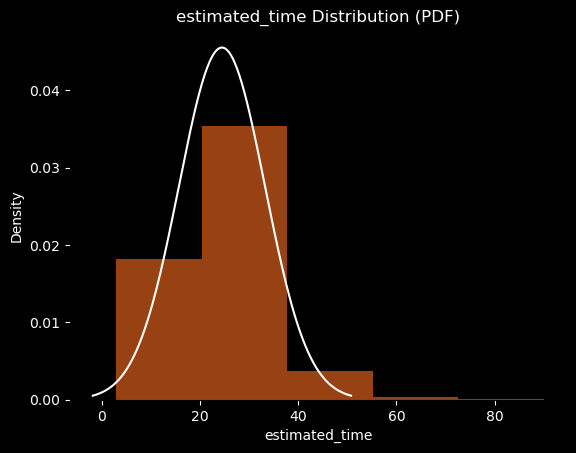

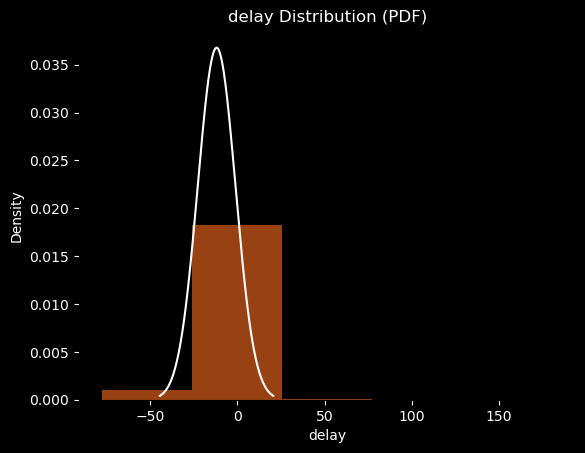

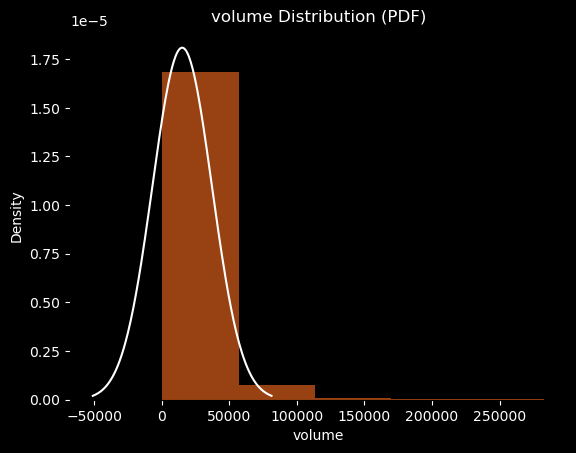

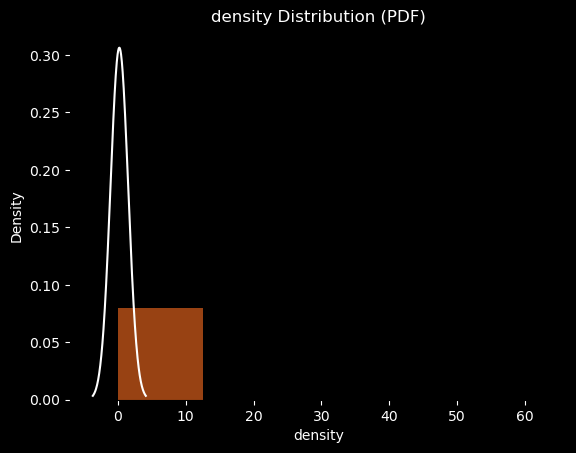

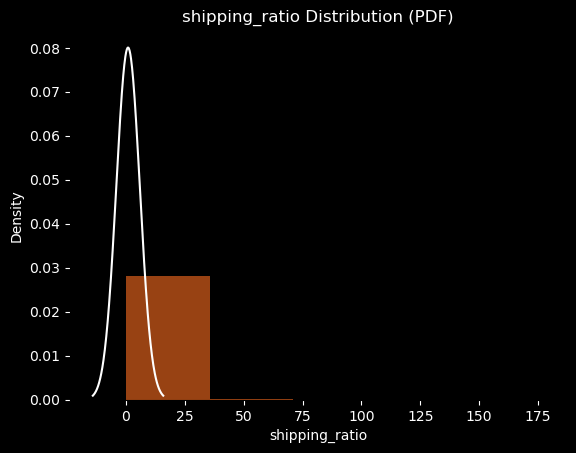

In [155]:
# Memabuat histrogram untuk melaukan pemeriksaan distribusi kerapatan data
dfc_col_num = dfc.select_dtypes(include='number').columns[1:]
# Membuat garis normalitas
for col in dfc_col_num:
    mu = dfc[col].mean()
    sigma = np.std(dfc[col])
    x = np.linspace(mu - 3*sigma, mu + 3*sigma, 200) 
    pdf = norm.pdf(x, mu, sigma)

    # Membuat histogram distribusi untuk setiap kolom numerik
    plt.hist(
        dfc[col], 
        bins = 5, 
        density=True, 
        alpha=0.6,
        color= "#FF6F20"
        )
    plt.plot(
        x, 
        pdf, 
        color='white'
        )
    
    plt.title(f"{col} Distribution (PDF)")
    plt.xlabel(f"{col}")
    plt.ylabel("Density")
    plt.show()

- seluruh distribusi data tidak normal

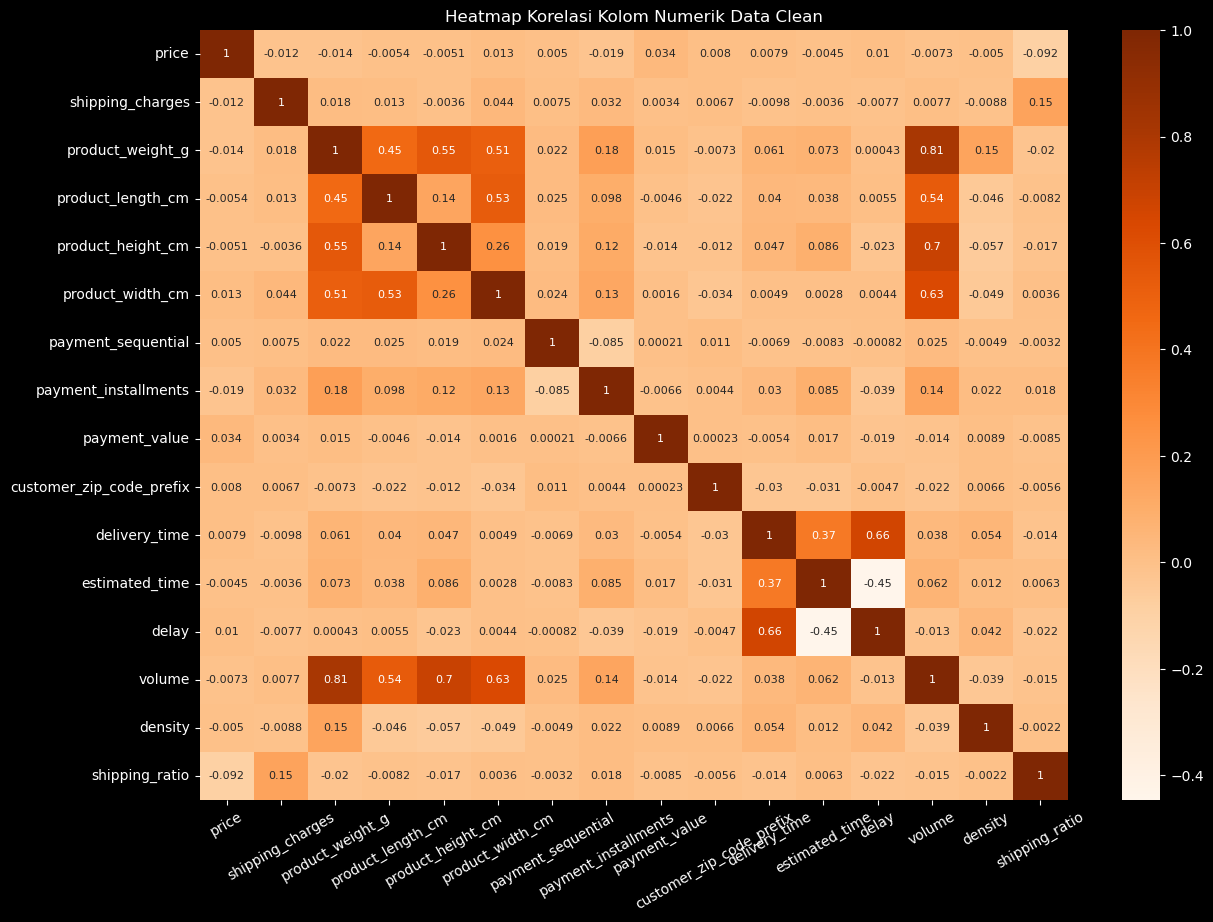

In [156]:
# Membuat dataframe kolom numerik
dfc_num = dfc.select_dtypes(include='number')

# Membuat heatmap korelasi kolom numerik
corr = dfc_num.corr()

plt.figure(figsize=(14,10))  # atur sesuai kebutuhan
# Heatmap untuk kolom numerik dataframe dfc
sns.heatmap(
    corr, 
    annot=True, 
    annot_kws={'size':8}, 
    cmap='Oranges'
    )

plt.title('Heatmap Korelasi Kolom Numerik Data Clean')
plt.xticks(rotation = 30)
plt.show()

In [157]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3639 entries, 0 to 99716
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       3639 non-null   object        
 1   customer_id                    3639 non-null   object        
 2   order_status                   3639 non-null   object        
 3   order_purchase_timestamp       3639 non-null   datetime64[ns]
 4   order_approved_at              3639 non-null   datetime64[ns]
 5   order_delivered_timestamp      3558 non-null   datetime64[ns]
 6   order_estimated_delivery_date  3639 non-null   datetime64[ns]
 7   product_id                     3639 non-null   object        
 8   seller_id                      3639 non-null   object        
 9   price                          3639 non-null   float64       
 10  shipping_charges               3639 non-null   float64       
 11  product_category_name

In [158]:
# Membuat heatmap untuk melihat korelasi pada kolom object atau kategorik
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(k-1, r-1))))

# ambil kolom kategorikal
cat_cols = dfc.select_dtypes(include='object').columns[2::]

# buat matrix
cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)

for col1 in cat_cols:
    for col2 in cat_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(dfc[col1], dfc[col2])

cramers_matrix = cramers_matrix.astype(float)

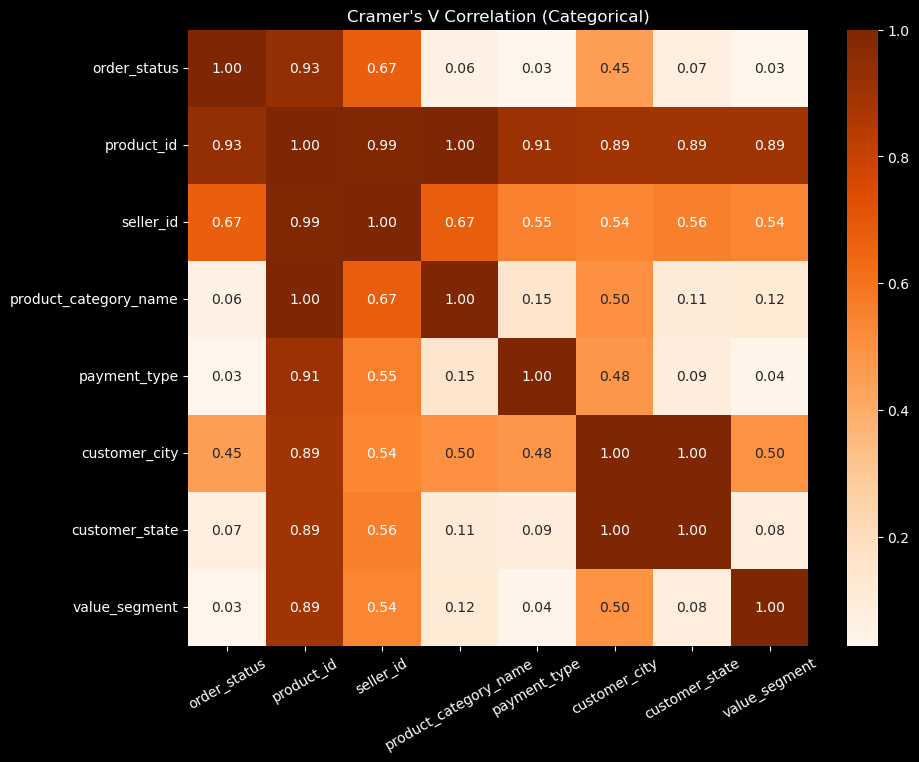

In [159]:
plt.figure(figsize=(10,8))
sns.heatmap(cramers_matrix, annot=True, cmap='Oranges', fmt='.2f')
plt.xticks(rotation = 30)
plt.title("Cramer's V Correlation (Categorical)")
plt.show()

- terdapat korelasi yang kuat antara product_id dengan customer_city, customer_state, payment_type, dan value_segment

In [160]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3639 entries, 0 to 99716
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       3639 non-null   object        
 1   customer_id                    3639 non-null   object        
 2   order_status                   3639 non-null   object        
 3   order_purchase_timestamp       3639 non-null   datetime64[ns]
 4   order_approved_at              3639 non-null   datetime64[ns]
 5   order_delivered_timestamp      3558 non-null   datetime64[ns]
 6   order_estimated_delivery_date  3639 non-null   datetime64[ns]
 7   product_id                     3639 non-null   object        
 8   seller_id                      3639 non-null   object        
 9   price                          3639 non-null   float64       
 10  shipping_charges               3639 non-null   float64       
 11  product_category_name

# Uji kruskal

In [161]:
# pastikan datetime
dfc['order_purchase_timestamp'] = pd.to_datetime(dfc['order_purchase_timestamp'])

# filter periode
df_period = dfc[
    (dfc['order_purchase_timestamp'] >= '2018-06-01') &
    (dfc['order_purchase_timestamp'] <= '2018-08-31')
]

print("Jumlah data:", len(df_period))

Jumlah data: 707


In [162]:
segments = df_period['value_segment'].unique()

group_data = []

for seg in segments:
    data = df_period[df_period['value_segment'] == seg]['delivery_time'].dropna()
    group_data.append(data)
    
    print(f"{seg}: {len(data)} data")

High: 158 data
Low: 169 data
Mid-High: 185 data
Mid-Low: 185 data


In [163]:
stat, p_value = kruskal(*group_data)

print("\nKruskal-Wallis Test (Jun–Aug 2018)")
print(f"Statistic: {stat:.4f}")
print(f"P-value: {p_value:.4f}")


Kruskal-Wallis Test (Jun–Aug 2018)
Statistic: 5.4488
P-value: 0.1417


In [164]:
alpha = 0.05

if p_value < alpha:
    print("Ada perbedaan signifikan delivery time antar segment (periode Jun–Aug)")
else:
    print(" Tidak ada perbedaan signifikan")

 Tidak ada perbedaan signifikan


# Membuat prediksi revenue 1 bulan berikutnya

In [165]:
# membuat variable time series
ts = dfc.groupby(
    dfc['order_purchase_timestamp'].dt.to_period('M')
)['payment_value'].sum().reset_index()

ts = ts.rename(columns={
    'order_purchase_timestamp' : 'month',
    'payment_value' : 'revenue'
})

ts.set_index('month', inplace=True)
ts

,revenue
month,
2016-10,2718.92
2017-01,7121.96
2017-02,15528.54
2017-03,22088.07
2017-04,29766.37
2017-05,35326.55
2017-06,30816.72
2017-07,47009.02
2017-08,40266.12


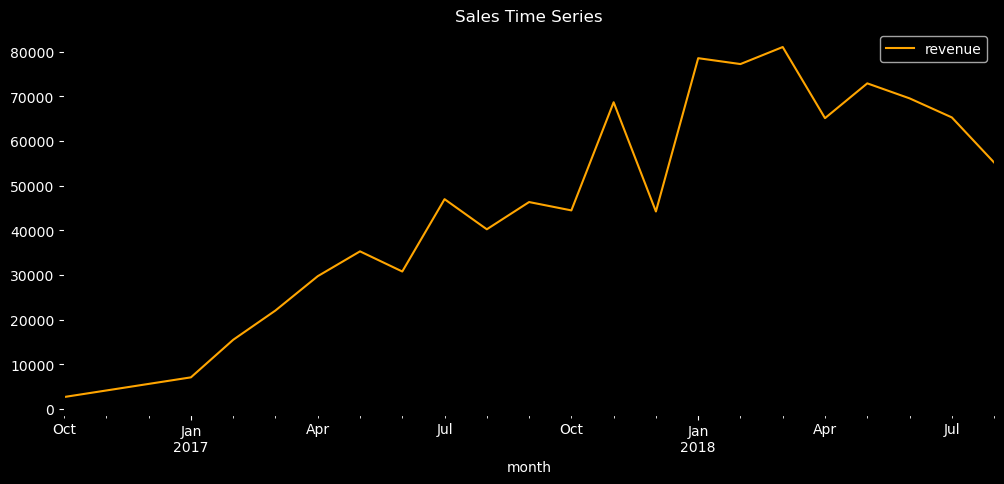

In [166]:
# grafik sales
ts.plot(
    figsize=(12,5),
    color='orange',
    title='Sales Time Series')
plt.show()

In [167]:
# agregasi revenue per segment per bulan
df_monthly = (
    dfc.groupby(['value_segment', 'year_month'])['payment_value']
    .sum()
    .reset_index()
)

# ubah ke datetime index
df_monthly['year_month'] = df_monthly['year_month'].dt.to_timestamp()
df_monthly

,value_segment,year_month,payment_value
0,High,2016-10-01,1408.95
1,High,2017-01-01,3493.90
2,High,2017-02-01,9707.39
3,High,2017-03-01,13382.05
4,High,2017-04-01,23033.98
...,...,...,...
79,Mid-Low,2018-04-01,10007.25
80,Mid-Low,2018-05-01,6575.21
81,Mid-Low,2018-06-01,6930.05
82,Mid-Low,2018-07-01,9133.48


In [168]:
# Fungsi pemeriksaan stationer
def check_stationarity(series):
    result = adfuller(series)
    
    return {
        'test_statistic': result[0],
        'p_value': result[1]
    }

In [169]:
# Lopping untuk melakukan prediksi revenue
final_models = {}
forecast_results = {}

for seg in df_monthly['value_segment'].unique():
    
    print(f"\n==============================")
    print(f"SEGMENT: {seg}")
    print(f"==============================")
    
    # Persiapan data model
    seg_data = df_monthly[df_monthly['value_segment'] == seg]
    
    ts = seg_data.set_index('year_month')['payment_value']
    ts.index = pd.to_datetime(ts.index)
    
    # fix frequency
    ts = ts.asfreq('MS')
    ts = ts.fillna(method='ffill')
    
    # Transformasi Log
    ts_log = np.log1p(ts)
    
    # Pemeriksaan stationery
    result = check_stationarity(ts_log)
    
    if result['p_value'] > 0.05:
        d = 1
        print("→ Not stationary (d=1)")
    else:
        d = 0
        print("→ Already stationary (d=0)")
    
    # Prediksi menggunakan model ARIMA
    best_aic = np.inf
    best_order = None
    best_model = None
    
    for p in [0,1]:
        for q in [0,1]:
            try:
                model = ARIMA(
                    ts_log,
                    order=(p,d,q),
                    enforce_stationarity=True,
                    enforce_invertibility=True
                )
                
                model_fit = model.fit(method='lbfgs', disp=0)
                
                if model_fit.aic < best_aic:
                    best_aic = model_fit.aic
                    best_order = (p,d,q)
                    best_model = model_fit
                    
            except:
                continue
    
    print(f"Best ARIMA: {best_order}")
    print(f"AIC: {best_aic:.2f}")
    
    final_models[seg] = best_model
    
    # Prediksi jika ARIMA tidak sesuai untuk melakukan prodiksi
    if best_model is None:
        print("Semua model gagal → pakai fallback (mean 3 bulan terakhir)")
        
        forecast = ts.tail(3).mean()
        forecast_results[seg] = forecast
        
        print(f"Fallback Forecast: {forecast:,.2f}")
        
    else:
        forecast_log = best_model.forecast(steps=1)
        forecast = np.expm1(forecast_log)
        
        forecast_results[seg] = forecast.values[0]
        
        print(f"Forecast next month: {forecast.values[0]:,.2f}")


SEGMENT: High
→ Already stationary (d=0)
Best ARIMA: None
AIC: inf
Semua model gagal → pakai fallback (mean 3 bulan terakhir)
Fallback Forecast: 37,868.02

SEGMENT: Low
→ Already stationary (d=0)
Best ARIMA: None
AIC: inf
Semua model gagal → pakai fallback (mean 3 bulan terakhir)
Fallback Forecast: 2,828.64

SEGMENT: Mid-High
→ Not stationary (d=1)
Best ARIMA: None
AIC: inf
Semua model gagal → pakai fallback (mean 3 bulan terakhir)
Fallback Forecast: 14,594.11

SEGMENT: Mid-Low
→ Already stationary (d=0)
Best ARIMA: None
AIC: inf
Semua model gagal → pakai fallback (mean 3 bulan terakhir)
Fallback Forecast: 8,079.30


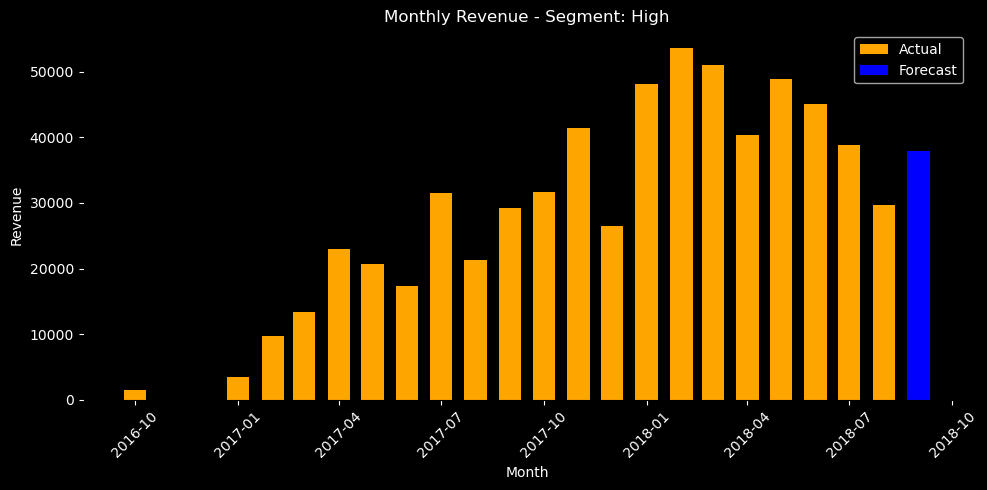

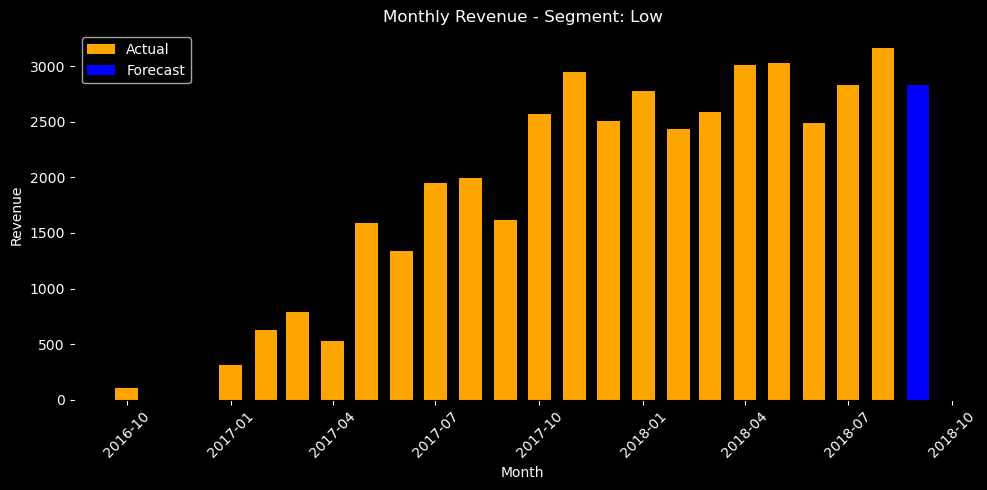

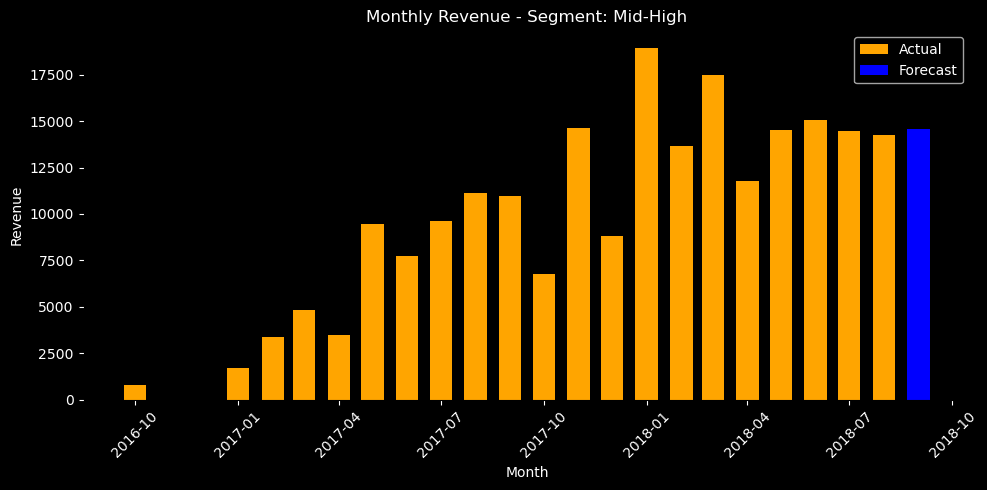

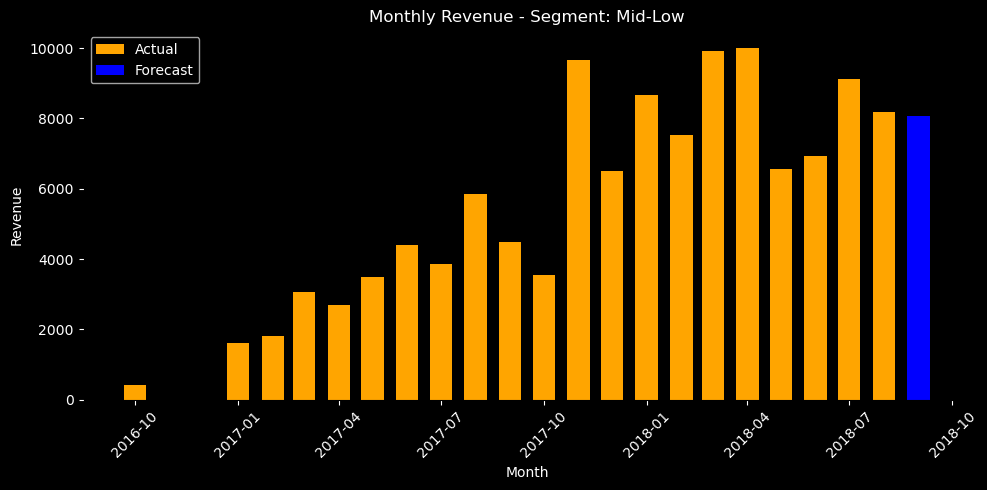

In [ ]:
segments = df_monthly['value_segment'].unique()

for seg in segments:
    seg_data = df_monthly[df_monthly['value_segment'] == seg].copy()
    
    # Ambil hasil forecast dari dictionary (pastikan kamu simpan sebelumnya)
    forecast_value = forecast_results[seg]
    
    # Buat tanggal bulan berikutnya
    last_date = seg_data['year_month'].max()
    next_month = last_date + pd.DateOffset(months=1)
    
    plt.figure(figsize=(10, 5))
    
    # Bar historis (orange)
    plt.bar(seg_data['year_month'], 
            seg_data['payment_value'], 
            width=20,
            color='orange',
            label='Actual')
    
    # Bar prediksi (biru)
    plt.bar(next_month, 
            forecast_value, 
            width=20,
            color='blue',
            label='Forecast')
    
    plt.title(f'Monthly Revenue - Segment: {seg}')
    plt.xlabel('Month')
    plt.ylabel('Revenue')
    plt.xticks(rotation=45)
    
    plt.legend()
    plt.tight_layout()
    plt.show()

In [171]:
# dfc.to_csv('CustomerSegmentationClean.csv', index=False)